Regiones y Fronteras

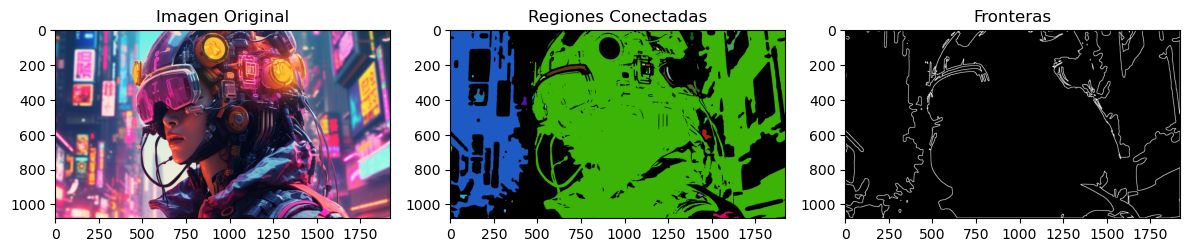

In [71]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('colores2.jpg')

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

#Combinacion de tecnicas
blur = cv2.GaussianBlur(gray, (7, 7), 0) #Valores impares
_,binary = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

#Encontrar contornos o regiones
num_l, label =cv2.connectedComponents(binary)

#Identificar por colores
color = np.random.randint(0, 255, size=(num_l, 3), dtype=np.uint8)

#Fondo negro
color[0] = [0, 0, 0]
colorear = color[label]

#Encontrar fronteras
contornos,_ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
contorno_fin = cv2.drawContours(np.zeros_like(gray), contornos, -1, (255, 0, 0), 2)


plt.figure(figsize=(12, 6))
plt.subplot(1, 3, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title('Imagen Original')
plt.subplot(1, 3, 2)
plt.imshow(colorear)
plt.title('Regiones Conectadas')
plt.subplot(1, 3, 3)
plt.imshow(contorno_fin,cmap='gray')
plt.title('Fronteras')
plt.tight_layout()
plt.show()

CONTEO

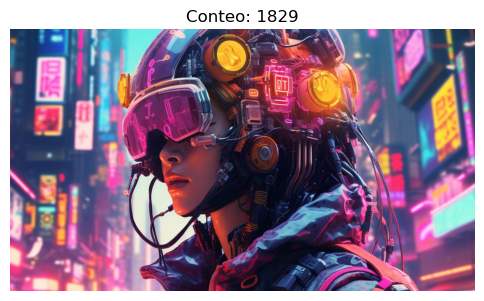

Cantidad de objetos: 1829


In [72]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import measure


def contar_elementos(img):
    gray=cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
    _,binary=cv2.threshold(gray,127,255,cv2.THRESH_BINARY)


    e_img=measure.label(binary,connectivity=2) # 2=conectividad es 4    1= con 8
    num_obj=np.max(e_img)
    return num_obj


img=cv2.imread('colores2.jpg')

resultado=contar_elementos(img)

plt.figure(figsize=(6,5))

plt.imshow(cv2.cvtColor(img,cv2.COLOR_BGR2RGB))
plt.title('Conteo: ' + str(resultado))
plt.axis('off')

plt.show()

print("Cantidad de objetos:", resultado)

Conteo Objetos 

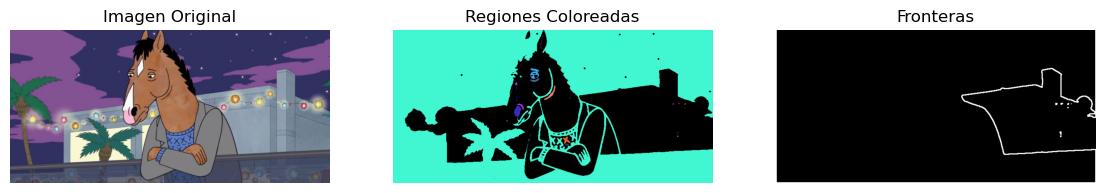

Regiones y cantidad de objetos:
Region 1 -- Objetos: 196753   -- Color: RGB(64,247,209)
Region 2 -- Objetos: 151   -- Color: RGB(37,15,30)
Region 3 -- Objetos: 2   -- Color: RGB(143,249,137)
Region 4 -- Objetos: 326   -- Color: RGB(57,171,236)
Region 5 -- Objetos: 22   -- Color: RGB(2,231,192)
Region 6 -- Objetos: 101   -- Color: RGB(67,106,153)
Region 7 -- Objetos: 37   -- Color: RGB(109,73,237)
Region 8 -- Objetos: 195   -- Color: RGB(246,121,108)
Region 9 -- Objetos: 6   -- Color: RGB(220,11,8)
Region 10 -- Objetos: 1   -- Color: RGB(34,35,24)
Region 11 -- Objetos: 1   -- Color: RGB(25,230,0)
Region 12 -- Objetos: 1   -- Color: RGB(224,86,221)
Region 13 -- Objetos: 1   -- Color: RGB(22,170,104)
Region 14 -- Objetos: 5   -- Color: RGB(158,156,102)
Region 15 -- Objetos: 15   -- Color: RGB(0,23,213)
Region 16 -- Objetos: 8   -- Color: RGB(103,28,41)
Region 17 -- Objetos: 11   -- Color: RGB(149,52,174)
Region 18 -- Objetos: 10   -- Color: RGB(90,34,171)
Region 19 -- Objetos: 7   -- Colo

In [79]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import measure

img = cv2.imread('imagen1.jpg')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
blur = cv2.GaussianBlur(gray, (7, 7), 0)
_, binary = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
label_img = measure.label(binary, connectivity=2)
num_regiones = label_img.max()

colores = np.random.randint(0, 255, size=(num_regiones + 1, 3), dtype=np.uint8)
colores[0] = [0, 0, 0]

props = measure.regionprops(label_img)
imagen_coloreada = colores[label_img]

contornos, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
contorno_fin  = cv2.drawContours(np.zeros_like(gray), contornos, -1, 255, 2)

plt.figure(figsize=(14, 5))
plt.subplot(1, 3, 1)
plt.imshow(img_rgb)
plt.title('Imagen Original')
plt.axis('off')
plt.subplot(1, 3, 2)
plt.imshow(imagen_coloreada)
plt.title('Regiones Coloreadas')
plt.axis('off')
plt.subplot(1, 3, 3)
plt.imshow(contorno_fin, cmap='gray')
plt.title('Fronteras')
plt.axis('off')
plt.show()

print('Regiones y cantidad de objetos:')
for prop in props:
    idx   = prop.label
    area  = int(prop.area)
    r_val, g_val, b_val = colores[idx]
    print('Region', idx, '-- Objetos:', area,'  -- Color: RGB(' + str(r_val) + ',' + str(g_val) + ',' + str(b_val) + ')')


